In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns

import scipy as sp

In [2]:
#importazione del dataset
df = pd.read_csv("Film_Genre_Stats.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   index                                           300 non-null    int64  
 1   Genre                                           300 non-null    str    
 2   Year                                            300 non-null    int64  
 3   Movies Released                                 300 non-null    int64  
 4   Gross                                           300 non-null    int64  
 5   Tickets Sold                                    300 non-null    int64  
 6   Inflation-Adjusted Gross                        300 non-null    int64  
 7   Top Movie                                       300 non-null    str    
 8   Top Movie Gross (That Year)                     300 non-null    int64  
 9   Top Movie Inflation-Adjusted Gross (That Year)  300 no

In [3]:
df.describe()

,index,Year,Movies Released,Gross,Tickets Sold,Inflation-Adjusted Gross,Top Movie Gross (That Year),Top Movie Inflation-Adjusted Gross (That Year)
count,300.000000,300.000000,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02
mean,149.500000,2006.963333,46.700000,7.382075e+08,1.078744e+08,9.676330e+08,1.350016e+08,1.766255e+08
std,86.746758,6.801189,60.938398,8.783016e+08,1.227454e+08,1.101026e+09,1.395006e+08,1.737089e+08
min,0.000000,1995.000000,1.000000,2.010000e+03,2.250000e+02,2.018000e+03,2.010000e+03,2.018000e+03
25%,74.750000,2001.000000,6.000000,5.786591e+07,8.275600e+06,7.423214e+07,2.528707e+07,3.603908e+07
50%,149.500000,2007.000000,25.000000,3.694118e+08,5.634667e+07,5.054296e+08,9.351396e+07,1.223360e+08
75%,224.250000,2013.000000,56.250000,1.294524e+09,1.859968e+08,1.668391e+09,1.886230e+08,2.841907e+08
max,299.000000,2018.000000,287.000000,4.159138e+09,4.851841e+08,4.352101e+09,7.422089e+08,8.478831e+08


In [4]:
# mi assicuro che ci siano solo le 300 righe non nulle
df.isnull().sum()

index                                             0
Genre                                             0
Year                                              0
Movies Released                                   0
Gross                                             0
Tickets Sold                                      0
Inflation-Adjusted Gross                          0
Top Movie                                         0
Top Movie Gross (That Year)                       0
Top Movie Inflation-Adjusted Gross (That Year)    0
dtype: int64

In [5]:
# Rinomino le varie colonne
df.rename(columns={'Year':'year', 'Movies Released':'film_usciti', 'Gross':'lordo', 'Tickets Sold':'biglietti_venduti',
                   'Inflation-Adjusted Gross':'lordo_con_inflazione', 'Top Movie Gross (That Year)':'guadagno_miglior_film', 
                   'Top Movie Inflation-Adjusted Gross (That Year)':'gmf_infl', 
                   'Genre':'genere', 'Top Movie': 'miglior_film'}, inplace = True)
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  300 non-null    int64  
 1   genere                 300 non-null    str    
 2   year                   300 non-null    int64  
 3   film_usciti            300 non-null    int64  
 4   lordo                  300 non-null    int64  
 5   biglietti_venduti      300 non-null    int64  
 6   lordo_con_inflazione   300 non-null    int64  
 7   miglior_film           300 non-null    str    
 8   guadagno_miglior_film  300 non-null    int64  
 9   gmf_infl               300 non-null    float64
dtypes: float64(1), int64(7), str(2)
memory usage: 31.7 KB


,index,year,film_usciti,lordo,biglietti_venduti,lordo_con_inflazione,guadagno_miglior_film,gmf_infl
count,300.000000,300.000000,300.000000,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02,3.000000e+02
mean,149.500000,2006.963333,46.700000,7.382075e+08,1.078744e+08,9.676330e+08,1.350016e+08,1.766255e+08
std,86.746758,6.801189,60.938398,8.783016e+08,1.227454e+08,1.101026e+09,1.395006e+08,1.737089e+08
min,0.000000,1995.000000,1.000000,2.010000e+03,2.250000e+02,2.018000e+03,2.010000e+03,2.018000e+03
25%,74.750000,2001.000000,6.000000,5.786591e+07,8.275600e+06,7.423214e+07,2.528707e+07,3.603908e+07
50%,149.500000,2007.000000,25.000000,3.694118e+08,5.634667e+07,5.054296e+08,9.351396e+07,1.223360e+08
75%,224.250000,2013.000000,56.250000,1.294524e+09,1.859968e+08,1.668391e+09,1.886230e+08,2.841907e+08
max,299.000000,2018.000000,287.000000,4.159138e+09,4.851841e+08,4.352101e+09,7.422089e+08,8.478831e+08


In [6]:
# Conto i generi
df['genere'].nunique()

14

In [7]:
# Conto gli anni
df['year'].nunique()

24

In [8]:
# Provo a capire quanti film ci sono per ogni categoria
df.groupby('genere')['film_usciti'].sum().sort_values()

genere
Reality                      5
Multiple Genres             39
Concert or Performance      63
Western                     77
Musical                    170
Dark Comedy                174
Horror                     553
Romantic Comedy            574
Action                     956
Adventure                 1005
Thriller or Suspense      1024
Documentary               2143
Comedy                    2230
Drama                     4997
Name: film_usciti, dtype: int64

In [9]:
df.groupby('genere')['film_usciti'].mean().sort_values()

genere
Reality                     1.666667
Multiple Genres             2.166667
Concert or Performance      3.315789
Western                     3.666667
Dark Comedy                 7.250000
Musical                     7.391304
Horror                     23.041667
Romantic Comedy            23.916667
Action                     39.833333
Adventure                  41.875000
Thriller or Suspense       42.666667
Documentary                89.291667
Comedy                     92.916667
Drama                     208.208333
Name: film_usciti, dtype: float64

In [10]:
df.head(10)

,index,genere,year,film_usciti,lordo,biglietti_venduti,lordo_con_inflazione,miglior_film,guadagno_miglior_film,gmf_infl
0,0,Adventure,1995,29,771507571,177358047,1590901682,Toy Story,150148222,3.096160e+08
1,1,Adventure,1996,34,1290490033,291966054,2618935504,Independence Day,306169255,6.213435e+08
2,2,Adventure,1997,23,881902843,192135684,1723457085,Men in Black,250650052,4.898324e+08
3,3,Adventure,1998,29,1614467732,344236174,3087798481,Armageddon,201578182,3.855344e+08
4,4,Adventure,1999,27,1612432107,317407880,2847148684,Star Wars Ep. I: The Phantom Menace,430443350,7.600545e+08
5,5,Adventure,2000,30,1327311892,246254507,2208902928,How the Grinch Stole Christmas,253367455,4.216523e+08
6,6,Adventure,2001,32,2268870844,400844935,3595579067,Harry Potter and the Sorcerer’s Stone,300404434,4.760641e+08
7,7,Adventure,2002,45,2818919526,485184060,4352101018,Spider-Man,403706375,6.232781e+08
8,8,Adventure,2003,46,2424131447,402011823,3606046052,Finding Nemo,339714367,5.053462e+08
9,9,Adventure,2004,47,2887833719,465029564,4171315189,Shrek 2,441226247,6.373268e+08


In [11]:
df.groupby('genere').head(3)

,index,genere,year,film_usciti,lordo,biglietti_venduti,lordo_con_inflazione,miglior_film,guadagno_miglior_film,gmf_infl
0,0,Adventure,1995,29,771507571,177358047,1590901682,Toy Story,150148222,3.096160e+08
1,1,Adventure,1996,34,1290490033,291966054,2618935504,Independence Day,306169255,6.213435e+08
2,2,Adventure,1997,23,881902843,192135684,1723457085,Men in Black,250650052,4.898324e+08
24,24,Action,1995,29,1049544278,241274531,2164232543,Batman Forever,184031112,3.794848e+08
25,25,Action,1996,36,1222675745,276623456,2481312400,Twister,241688385,4.904852e+08
26,26,Action,1997,36,1456612580,317344773,2846582614,The Lost World: Jurassic Park,229086679,4.476922e+08
48,48,Drama,1995,131,1525963099,350796050,3146640569,Apollo 13,172036360,3.547508e+08
49,49,Drama,1996,121,1373074715,310650329,2786533451,A Time to Kill,108766007,2.207310e+08
50,50,Drama,1997,117,1198241550,261054747,2341661081,The Godfather,129141981,2.523755e+08
72,72,Comedy,1995,61,1048895722,241125423,2162895044,Ace Ventura: When Nature Calls,104371496,2.152212e+08


In [12]:
df.groupby('genere').tail(3)

,index,genere,year,film_usciti,lordo,biglietti_venduti,lordo_con_inflazione,miglior_film,guadagno_miglior_film,gmf_infl
21,21,Adventure,2016,53,4159137913,478096752,4288527865,Finding Dory,486295561,5.014241e+08
22,22,Adventure,2017,44,2687890267,299653307,2687890164,Star Wars Ep. VIII: The Last Jedi,517218368,5.172183e+08
23,23,Adventure,2018,49,2973509668,331494935,2973509567,Incredibles 2,608581744,6.085817e+08
45,45,Action,2016,61,2533249471,289951566,2600865547,Captain America: Civil War,408084349,4.189767e+08
46,46,Action,2017,67,3305708764,368529372,3305708467,Wonder Woman,412563408,4.125634e+08
47,47,Action,2018,59,4142067464,461768924,4142067248,Black Panther,700059566,7.000595e+08
69,69,Drama,2016,282,1360947564,156363340,1402579160,Sully,124976335,1.287994e+08
70,70,Drama,2017,253,1326577328,147890338,1326576332,Hidden Figures,167620331,1.676202e+08
71,71,Drama,2018,266,1631625937,181897975,1631624836,A Star is Born,202110097,2.021100e+08
93,93,Comedy,2016,98,1409767232,161840867,1451712577,Ghostbusters,128350574,1.321694e+08


In [13]:
# Le medie molto piccole di prima mi fanno sospettare che non tutti i generi abbiano film usciti ogni anno
df['genere'].value_counts()

genere
Adventure                 24
Action                    24
Drama                     24
Comedy                    24
Thriller or Suspense      24
Horror                    24
Romantic Comedy           24
Documentary               24
Dark Comedy               24
Musical                   23
Western                   21
Concert or Performance    19
Multiple Genres           18
Reality                    3
Name: count, dtype: int64

In [14]:
# Aggiungo una colonna per il guadagno medio per film di ogni anno
df['guad_medio_film'] = df['lordo']/df['film_usciti']
df.head(5)

,index,genere,year,film_usciti,lordo,biglietti_venduti,lordo_con_inflazione,miglior_film,guadagno_miglior_film,gmf_infl,guad_medio_film
0,0,Adventure,1995,29,771507571,177358047,1590901682,Toy Story,150148222,3.096160e+08,2.660371e+07
1,1,Adventure,1996,34,1290490033,291966054,2618935504,Independence Day,306169255,6.213435e+08,3.795559e+07
2,2,Adventure,1997,23,881902843,192135684,1723457085,Men in Black,250650052,4.898324e+08,3.834360e+07
3,3,Adventure,1998,29,1614467732,344236174,3087798481,Armageddon,201578182,3.855344e+08,5.567130e+07
4,4,Adventure,1999,27,1612432107,317407880,2847148684,Star Wars Ep. I: The Phantom Menace,430443350,7.600545e+08,5.971971e+07


In [15]:
# Aggiungo una colonna per il guadagno medio per biglietto di ogni anno
df['guad_medio_biglietto'] = df['lordo']/df['biglietti_venduti']
df.head(5)


,index,genere,year,film_usciti,lordo,biglietti_venduti,lordo_con_inflazione,miglior_film,guadagno_miglior_film,gmf_infl,guad_medio_film,guad_medio_biglietto
0,0,Adventure,1995,29,771507571,177358047,1590901682,Toy Story,150148222,3.096160e+08,2.660371e+07,4.35
1,1,Adventure,1996,34,1290490033,291966054,2618935504,Independence Day,306169255,6.213435e+08,3.795559e+07,4.42
2,2,Adventure,1997,23,881902843,192135684,1723457085,Men in Black,250650052,4.898324e+08,3.834360e+07,4.59
3,3,Adventure,1998,29,1614467732,344236174,3087798481,Armageddon,201578182,3.855344e+08,5.567130e+07,4.69
4,4,Adventure,1999,27,1612432107,317407880,2847148684,Star Wars Ep. I: The Phantom Menace,430443350,7.600545e+08,5.971971e+07,5.08


In [16]:
df.groupby('genere')['guad_medio_biglietto'].head(3)

0      4.350000
1      4.420000
2      4.590000
24     4.350000
25     4.420000
26     4.590000
48     4.350001
49     4.420001
50     4.590001
72     4.350001
73     4.420001
74     4.590001
96     4.350000
97     4.420001
98     4.590000
120    4.350001
121    4.420001
122    4.590000
144    4.350001
145    4.420000
146    4.590001
168    4.420012
169    4.590000
170    4.690001
191    4.350001
192    4.420013
193    4.590008
215    4.350002
216    4.420009
217    4.590001
239    4.350001
240    4.420024
241    5.080007
260    5.080011
261    5.390001
262    5.660018
279    5.390013
280    5.661972
281    5.810041
297    8.171928
298    8.430126
299    9.008889
Name: guad_medio_biglietto, dtype: float64

year
1995     5313833988
1996     5786385010
1997     6346778910
1998     6761067542
1999     7322805943
2000     7518168735
2001     8283644803
2002     9141121350
2003     9175369465
2004     9284271806
2005     8800787012
2006     9157957897
2007     9768139446
2008     9750515357
2009    10624288879
2010    10457815128
2011    10170132305
2012    11162128340
2013    10878819789
2014    10278900346
2015    11155094542
2016    11258658033
2017    10992959545
2018    12072609053
Name: lordo, dtype: int64

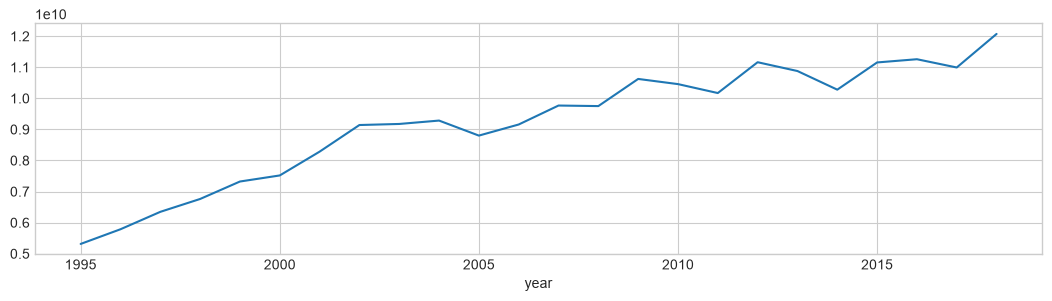

In [28]:
#1) incassi
dfTest = df.groupby('year')['lordo'].sum()

plt.figure(figsize = (13, 3))
sns.lineplot(x = dfTest.index , y = dfTest.values)

dfTest.head(24) # numero anni

<Axes: xlabel='film_usciti', ylabel='lordo'>

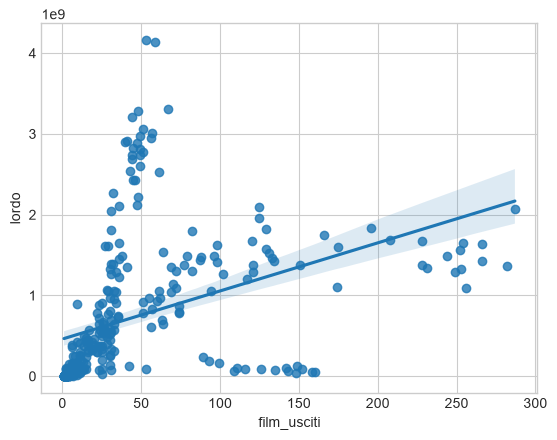

In [18]:
sns.regplot(x=df['film_usciti'], y=df['lordo'])

<Axes: xlabel='film_usciti', ylabel='biglietti_venduti'>

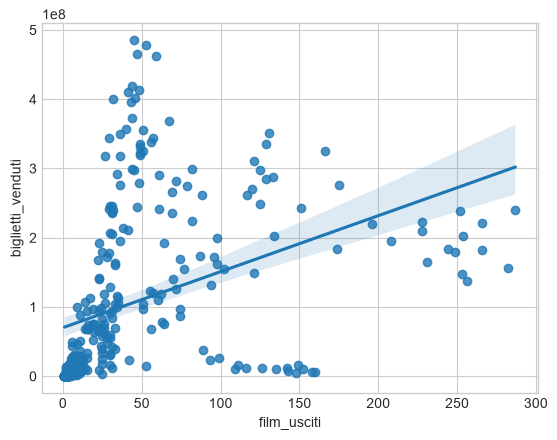

In [19]:
sns.regplot(x=df['film_usciti'], y=df['biglietti_venduti'])

In [20]:
sp.stats.pearsonr(df['film_usciti'],df['biglietti_venduti'])

PearsonRResult(statistic=np.float64(0.4012813943409383), pvalue=np.float64(4.923170137941587e-13))

In [21]:
sp.stats.spearmanr(df['film_usciti'],df['biglietti_venduti'])

SignificanceResult(statistic=np.float64(0.7617236888714081), pvalue=np.float64(4.087046932711105e-58))

In [22]:
sp.stats.kendalltau(df['film_usciti'],df['biglietti_venduti'])

SignificanceResult(statistic=np.float64(0.5867803239680891), pvalue=np.float64(5.0982587021954975e-51))

<Axes: xlabel='totale_film', ylabel='totale_guadagni'>

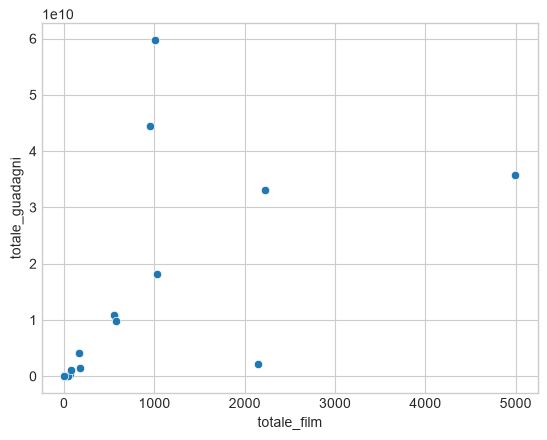

In [23]:
df_generi = df.groupby('genere').agg(totale_film=('film_usciti', 'sum'), totale_guadagni=('lordo', 'sum'))
df_generi
sns.scatterplot(data=df_generi, x = 'totale_film', y = 'totale_guadagni')

<Axes: xlabel='film_usciti', ylabel='lordo'>

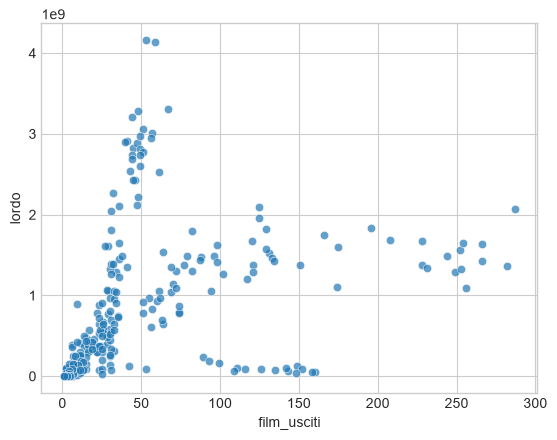

In [24]:


# Relazione tra film usciti e lordo
sns.scatterplot(data=df, x='film_usciti', y='lordo', alpha=0.7)


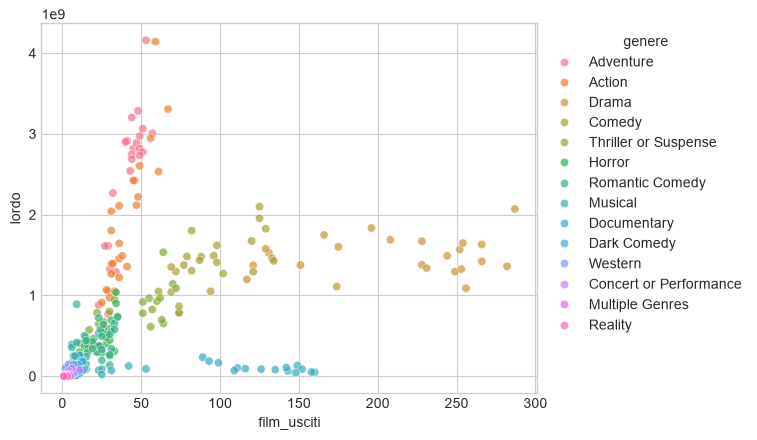

In [25]:
# magari il genere conta sulla resa del film --> sembra di sì
# Relazione tra film usciti e lordo e genere
grafico = sns.scatterplot(data=df, x='film_usciti', y='lordo', hue='genere', alpha=0.7)
# La legenda in mezzo da fastidio
sns.move_legend(grafico, "upper left", bbox_to_anchor=(1, 1))

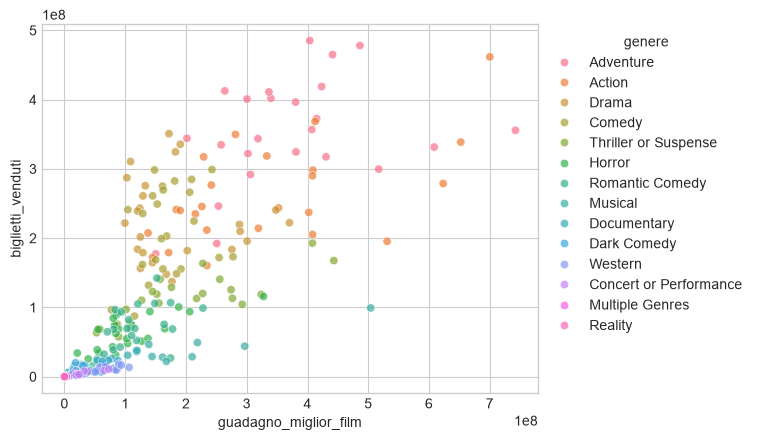

In [26]:
# generi in cui se sbanchi, sbanchi sul serio
grafico = sns.scatterplot(data=df, x='guadagno_miglior_film', y='biglietti_venduti', hue='genere', alpha=0.7)
sns.move_legend(grafico, "upper left", bbox_to_anchor=(1, 1))

In [27]:
df.to_pickle("Film.pickle")